<h2> Nauczanie maszynowe/Ćwiczenia2

20.10.25 Jadwiga Krząstek

Zagadnienia na dziś:
- Regresja wielomianowa
- Regresja logistyczna
- Regularyzacja
- Reprezentacja sekwencji biologicznych

<h4> Zadanie1 (1pkt): Rozważamy dane dotyczące ekspresji genów z odpowiedzi ludzkich astrocytów U251 na zakażenie wirusem grypy H5N1. Badanie to dostarcza informacji na temat odpowiedzi immunologicznej astrocytów na infekcję wirusową.

<h4>
    
- Narysuj zależność $LIF$ vs $SHPRH$ oraz $LIF$ vs $IL11$. Skomentuj otrzymane wykresy (także biologicznie, co to może oznaczać?).  
- Zaproponuj adekwatną zależność $LIF \sim f_1(SHRPH)+f_2(IL11)+$, gdzie $f_1$ i $f_2$ to pewne tranformacje (np. wielomianowe). Uzasadnij swój wybór. Nie wydzielaj zbiorów: treningowego/testowego (mało danych). 
- Wyznacz MSE dla modelu oraz narysuj zależność $LIF$ vs $LIF^p$.

* LIF/IL11 to cytokiny z rodziny IL6, aktywujące szlak JAK/STAT3
* SHPRH jest z kolei zaangażowany w naprawę DNA i stabilność genomu

In [4]:
df = pd.read_csv('genes_cig.txt', sep = ",")
df.head()

,LIF,IL11,SHPRH
0,9.19007,7.25721,6.79607
1,9.26944,7.65776,6.71755
2,9.35100,7.62542,6.80711
3,8.64706,7.37893,6.83646
4,8.92314,7.60337,7.07751


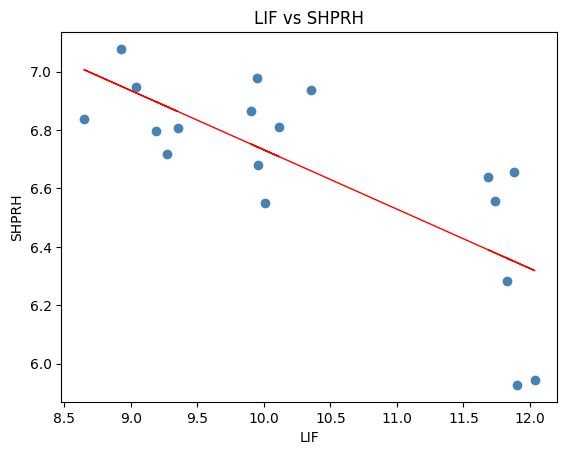

In [17]:
#wykres 1: LIF vs SHPRH + linia trendu za pomocą Linear Regression
from sklearn.linear_model import LinearRegression

X = df["LIF"].values.reshape(-1, 1)
y = df["SHPRH"].values

reg = LinearRegression()
reg.fit(X, y)

y_pred = reg.predict(X)

plt.scatter(X, y, color="steelblue")
plt.plot(X, y_pred, color="red", linewidth=1) #BONUS: linia trendu
plt.xlabel("LIF")
plt.ylabel("SHPRH")
plt.title("LIF vs SHPRH")
plt.show()

1. LIF vs SHPRH

**Korelacja:** słaba lub ujemna.

SHPRH odpowiada za naprawę DNA i stabilność genomu, jego ekspresja może być aktywowana w warunkach stresu komórkowego, natomiast LIF to cytokina aktywująca proliferację i różnicowanie przez JAK/STAT3.

Komórki aktywujące odpowiedź zapalną (wysoki LIF) nie mają silnej ekspresji genów naprawy DNA (SHPRH). Wysoka aktywność szlaków proliferacyjnych (LIF) może tymczasowo obniżać ekspresję genów naprawczych, np. by zmniejszać stabilność genomu i ułatwić podziały komórkowe.

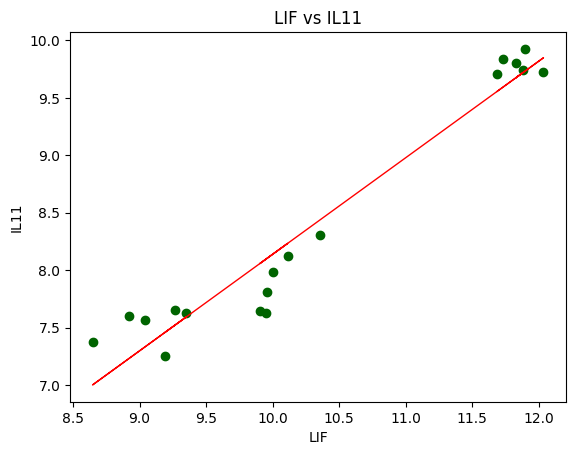

In [20]:
#wykres 2: LIF vs IL11 + linia trendu za pomocą Linear Regression
X = df["LIF"].values.reshape(-1, 1)
y = df["IL11"].values

reg = LinearRegression()
reg.fit(X, y)

y_pred = reg.predict(X)

plt.scatter(X, y, color="darkgreen")
plt.plot(X, y_pred, color="red", linewidth=1) #BONUS: linia trendu
plt.xlabel("LIF")
plt.ylabel("IL11")
plt.title("LIF vs IL11")
plt.show()

2. LIF vs IL11

**Korelacja:** mocna dodatnia. Gdy wzrasta LIF wzrasta także IL11.

LIF i IL11 są cytokinami z rodziny IL6, są aktywowane przez podobne czynniki zapalne i hormonalne i aktywują szlak sygnałowy JAK/STAT3, dlatego ich ekspresja rośnie jednocześnia w komórkach reagujących na stres, stan zapalny czy proliferację.

Można wysunąć wniosek, że LIF i IL11 **współpracują** w odpowiedzi na czynniki wzrostu i cytokiny, regulując procesy takie jak transkrypcja, proliferacja, różnicowanie i przeżycie komórek.

MSE: 1.5176
MSE po dopasowaniu wag przez gradient descent: 0.1243
Wyuczone wagi: w1=0.1937, w2=0.9669, w0=0.9109


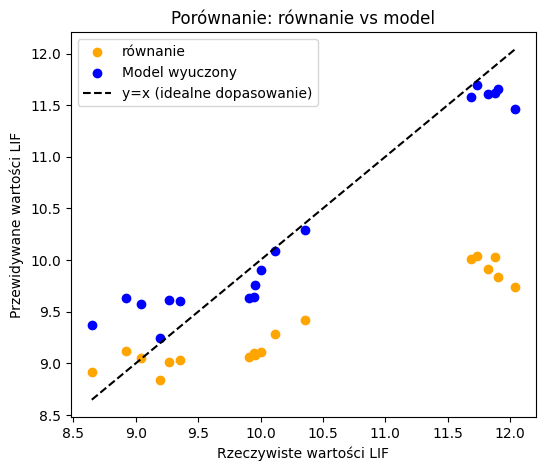

In [21]:
#X[:,0] = SHPRH, X[:,1] = IL11
X = df[["SHPRH", "IL11"]].values
t = df["LIF"].values

#testowe rownanie
#y_pred = 3 * X[:,0] - 2 * X[:,1]
#y_pred = 5*X[:,0]- 2*X[:,1]
#y_pred = 3*X[:,0] + 4*X[:,1] - 42
#y_pred = -X[:,0] + 5*X[:,1]
#y_pred = X[:,0]**2 - X[:,1] -30
#y_pred = np.log1p(X[:,0]) + 2*X[:,1] - 7
y_pred = 2*np.sqrt(np.abs(X[:,0])) + 0.5*X[:,1] #najlepszy z zaproponowanych modeli


MSE = np.mean((y_pred - t)**2)
print(f"MSE: {MSE:.4f}")

model = LinearModel2v(eta=0.001)
model.train(X, t)
mse_trained = model.loss_function(X, t)

print(f"MSE po dopasowaniu wag przez gradient descent: {mse_trained:.4f}")
print(f"Wyuczone wagi: w1={model.w1:.4f}, w2={model.w2:.4f}, w0={model.w0:.4f}")

plt.figure(figsize=(6,5))
plt.scatter(t, y_pred, color="orange", label="równanie")
plt.scatter(t, X[:,0]*model.w1 + X[:,1]*model.w2 + model.w0,
            color="blue", label="Model wyuczony")
plt.plot([t.min(), t.max()], [t.min(), t.max()], "k--", label="y=x")
plt.xlabel("Rzeczywiste wartości LIF")
plt.ylabel("Przewidywane wartości LIF")
plt.legend()
plt.title("Porównanie: równanie vs model")
plt.show()

**Komentarz**

4 pierwsze równania wykazują dość prostą zależność i okazały się nieoptymalne, np. wykazują zbyt silny efekt IL11, przez co model przeszacowuje duże wartości lub mają zbyt wysokie współczynniki powodujące niestabilność modelu.
Po przetestowaniu tych równań odkryto, że konieczne jest wprowaadzanie bardziej złożonych zależności.

**Wniosek** 

Najlepsze modele to te, które **łagodzą wpływ SHPRH** (np. √|x₁|) i umiarkowanie **wzmacniają IL11** (np. 0.5·x₂), a najsłabsze to te, które nadmiernie zwiększają wpływ którejś zmiennej (duże współczynniki lub potęgi). 

W najlepszym równaniu dodatni współczynnik przy IL11 potwierdza współregulację: wzrost IL11 → wzrost LIF. Dodatkowo model używa pierwiastka √|x₁|, co sugeruje nieliniowy, słabnący wpływ: przy małym SHPRH — LIF wzrasta, a przy dużym SHPRH — efekt zwalnia (priorytetem staje się naprawa, nie proliferacja). Modele z kwadratem (x₁²) lub dużymi współczynnikami (np. 5·x₁) przeszacowują ten efekt (w +nieskończoności) i źle odwzorowują rzeczywistość.

**Interpretacja**

Biologicznie opisana zależność to współdziałanie cytokin IL11 i LIF w aktywacji szlaku JAK/STAT3 oraz ograniczony wpływ genów naprawy DNA (SHPRH) na poziom cytokin w warunkach stresu komórkowego.

<h4> Zadanie2 (3pkt): Rozważ dane dotyczace lokalizacji komórkowej wybranych białek (peptydów).
    
- Pozostaw kategorie: MT (mitochondrialne), SP (sygnałowe), CH (chloroplastów), TH (lumen tylakoidów), czyli odrzuć rekordy Other
- Czy rozważany zbiór danych jest zbalansowany?
- Wybierz cechy do reprezentacji rozważanych sekwencji
- Narysuj histogramy/wykresy pudełkowe rozważanych cech względem kategorii
- Podziel dane na zbiór treningowy i testowy (ewentualnie wydziel jeszcze zbiór walidacyjny)
- Dokonaj standaryzacji danych
- Zbuduj model regresji logistycznej, które zmienne najbardziej istotne?

!!!Zbuduj wiele modeli, pokazując proces tworzenia bardziej użytecznych modeli!!! Co warto zrobić?
- class_weight='balanced' jako argument LR
- SMOTE (z imblearn) - dogenerować kolejne dane
- wybór innych cech
- rozważ nieliniowe transformacje
- rozważ regularyzację (zwłaszcza przy dużej liczbie cech)
- ... im więcej ciekawych pomysłów tym lepiej

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from collections import Counter
from Bio import SeqIO

In [2]:
#WCZYTANIE I PRZYGOTOWANIE DANYCH, WYBÓR REPREZENTACJI
df = pd.read_csv("swissprot_annotated_proteins.tab", sep="\t", header=None)
df.columns = ["protein_id", "localization", "feature"]
print(df.head())

seq_data = []
for record in SeqIO.parse("targetp.fasta", "fasta"):
    seq_data.append({"protein_id": record.id, "sequence": str(record.seq)})

seq_df = pd.DataFrame(seq_data)
print(seq_df.head())

#łaczenie danych
merged_df = pd.merge(df, seq_df, on="protein_id", how="inner")
print(f"\nPołączono dane: {merged_df.shape[0]} rekordów")
print(merged_df.head())

merged_df = merged_df[merged_df["localization"] != "Other"].copy()

print("\nLiczność po odrzuceniu 'Other':")
print(merged_df["localization"].value_counts())

  protein_id localization  feature
0     P10719           MT       46
1     Q38786           CH       55
2     P15289           SP       18
3     P25705           MT       43
4     P00829           MT       48
  protein_id                                           sequence
0     P92192  MKFLIVFVALFAMAVARPNLAEIVRQVSDVEPEKWSSDVETSDGTS...
1     P30042  MAAVRALVASRLAAASAFTSLSPGGRTPSQRAALHLSVPRPAARVA...
2     Q9D666  MDFSRLHTYTPPQCVPENTGYTYALSSSYSSDALDFETEHKLEPVF...
3     Q9BUL9  MENFRKVRSEEAPAGCGAEGGGPGSGPFADLAPGAVHMRVKEGSKI...
4     U6A629  MLAEYLLLPLLASYASAVTISVAKSGGNVTTGLQYGAMEEEINHCG...

Połączono dane: 13005 rekordów
  protein_id localization  feature  \
0     P10719           MT       46   
1     Q38786           CH       55   
2     P15289           SP       18   
3     P25705           MT       43   
4     P00829           MT       48   

                                            sequence  
0  MLSLVGRVASASASGALRGLNPLAALPQAHLLLRTAPAGVHPARDY...  
1  MALLCSALSNSTHPSFRSHIGANSENLWHLSA

### Próba 1: wyliczanie własności ręcznie
Reprezentacja sekwencji - obliczanie zawartości procentowej aminokwasów danej grupy w całej sekwencji

In [10]:
def seq_features(seq):
    seq = seq.upper()
    length = len(seq)
    hydrophobic = sum(aa in "AILMFWYV" for aa in seq) / length
    acidic = sum(aa in "DE" for aa in seq) / length
    basic = sum(aa in "KRH" for aa in seq) / length
    polar = sum(aa in "STNQ" for aa in seq) / length
    return pd.Series([length, hydrophobic, acidic, basic, polar])

merged_df[["length", "hydrophobic", "acidic", "basic", "polar"]] = merged_df["sequence"].apply(seq_features)
X = merged_df[["length", "hydrophobic", "acidic", "basic", "polar"]].values
y = merged_df["localization"].values

#SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

balanced_df = pd.DataFrame(X_res, columns=["length", "hydrophobic", "acidic", "basic", "polar"])
balanced_df["localization"] = y_res

print("\nLiczności po zbilansowaniu:")
print(balanced_df["localization"].value_counts())


Liczności po zbilansowaniu:
localization
MT    2697
CH    2697
SP    2697
TH    2697
Name: count, dtype: int64


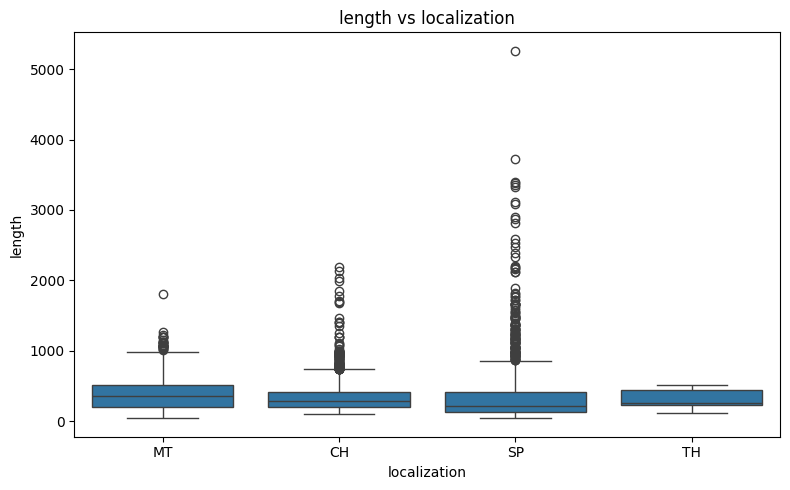

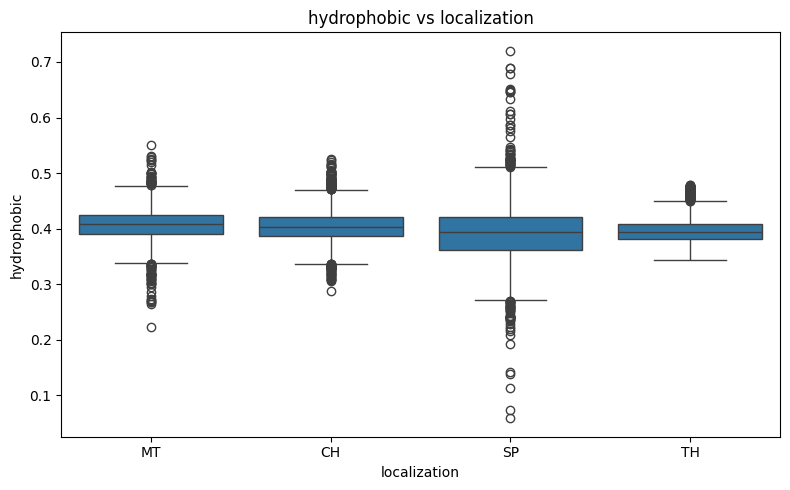

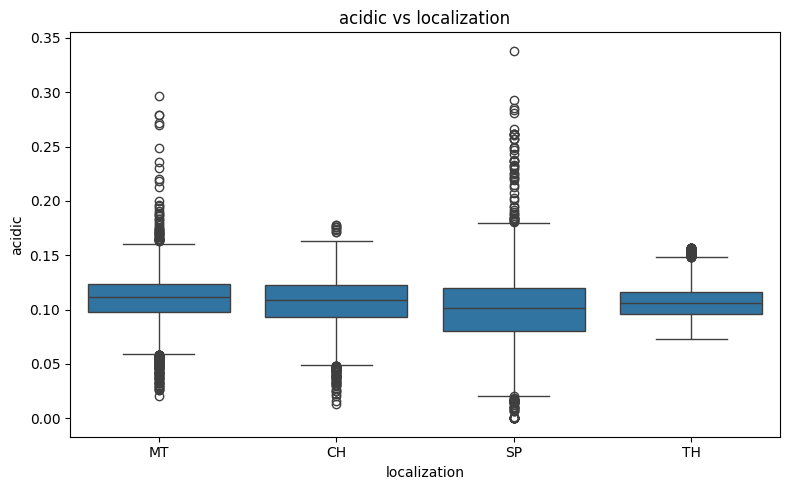

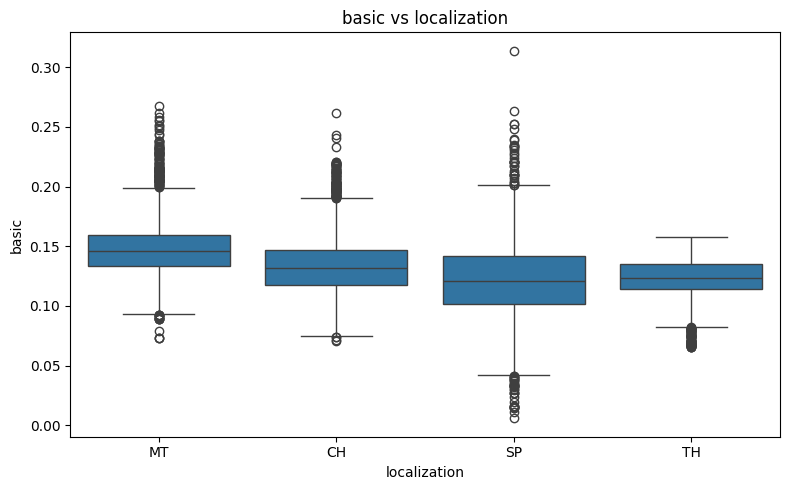

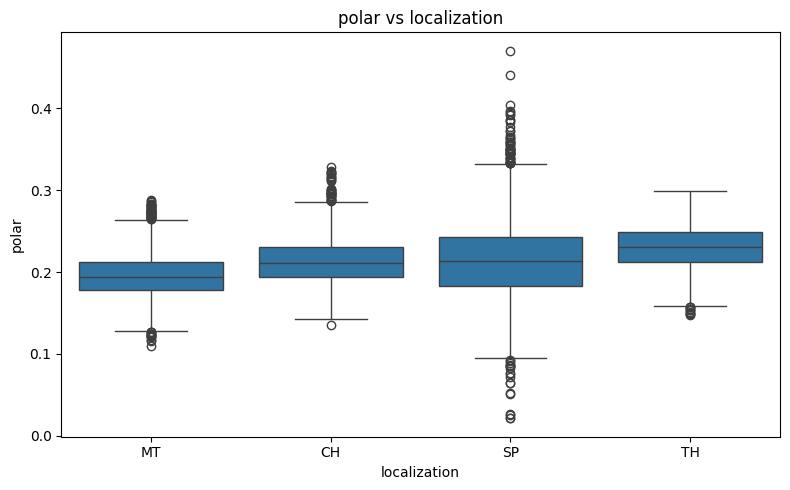

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["length", "hydrophobic", "acidic", "basic", "polar"]

for feat in features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=balanced_df, x="localization", y=feat)
    plt.title(f"{feat} vs localization")
    plt.tight_layout()
    plt.show()


**Komentarz**

Cechy charakterystyczne: 
- długość (CH, SP) - białka chloroplastowe i mitochondrialne często mają długie presekwencje kierujące, białka sygnałowe – krótsze
- hydrofobowość (SP) - hydrofobowe fragmenty tworzą helisy błonowe i sygnały transportowe
- kwasowość (SP, MT) - ujemny ładunek utrudnia przechodzenie przez błony biologiczne
- polarność (SP, MT) - polarność wiąże się z rozpuszczalnością w cytoplazmie i transportem przez stromę chloroplastów
- odsetek zasadowych aminokwasów w sekwencji (MT, SP) - dodatni ładunek wiąże się z presekwencjami mitochondrialnymi i jądrowymi

Wykres pudełkowy basic w różnych kategoriach lokalizacji (MT, SP, CH, TH) pokazuje różnice biologiczne między klasami.



---------

Białka mitochondrialne (MT) charakteryzują się wysokim udziałem reszt zasadowych (basic), co jest zgodne z faktem, że presekwencje mitochondrialne są bogate w lizynę i argininę, przyciągane elektrostatycznie przez błonę mitochondrium.

Z kolei białka sygnałowe (SP) mają wyraźnie wyższy udział aminokwasów hydrofobowych (hydrophobic), co odpowiada obecności hydrofobowej helisy sygnałowej umożliwiającej wnikanie w błonę retikulum endoplazmatycznego.

Białka chloroplastowe (CH) wyróżniają się większym udziałem aminokwasów polarnych (polar), a niższym udziałem zasadowych, co jest charakterystyczne dla presekwencji stromalnych.

Długość sekwencji (length) również różnicuje klasy — presekwencje chloroplastowe i mitochondrialne są dłuższe niż sygnałowe.

Takie zróżnicowanie wartości potwierdza, że wybrane cechy (hydrophobic, acidic, basic, polar, length) dobrze opisują biologicznie relewantne właściwości sekwencji i są przydatne w klasyfikacji lokalizacji białek.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter

#train/test (80/20), train/val (60/20/20)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

#standaryzacja danych tylko na zbiorze treningowym
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [20]:
model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_val_scaled)

acc_val = accuracy_score(y_val, y_pred)
print(f"Accuracy: {acc_val:.4f}")

print("\nRaport klasyfikacji")
print(classification_report(y_res, model.predict(StandardScaler().fit_transform(X_res)), target_names=np.unique(y_res)))

Accuracy (validation): 0.4838

Raport klasyfikacji
              precision    recall  f1-score   support

          CH       0.38      0.24      0.29      2697
          MT       0.53      0.69      0.60      2697
          SP       0.49      0.44      0.46      2697
          TH       0.52      0.61      0.56      2697

    accuracy                           0.49     10788
   macro avg       0.48      0.49      0.48     10788
weighted avg       0.48      0.49      0.48     10788



Komentarz: wyniki średnie, bliskie losowym.

### Próba 2: Biopython
Tym razem rozważane będą własności:
 - molecular_weight
 - isoelectric_point
 - gravy
 - aromaticity
 - instability_index

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio import SeqIO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import seaborn as sns

In [4]:
def extract_protein_features(seq):
    seq = seq.upper()
    seq = ''.join([aa for aa in seq if aa in "ACDEFGHIKLMNPQRSTVWY"])
    if len(seq) == 0:
        return pd.Series([np.nan]*8, index=[
            "molecular_weight", "isoelectric_point", "gravy", "aromaticity",
            "instability_index", "helix", "sheet", "turn"
        ])
    p = ProteinAnalysis(seq)
    ssf = p.secondary_structure_fraction()
    return pd.Series([
        p.molecular_weight(),
        p.isoelectric_point(),
        p.gravy(),
        p.aromaticity(),
        p.instability_index(),
        ssf[0],  #helix
        ssf[1],  #sheet
        ssf[2]   #turn
    ], index=[
        "molecular_weight", "isoelectric_point", "gravy", "aromaticity",
        "instability_index", "helix", "sheet", "turn"
    ])


In [5]:
protein_features = merged_df["sequence"].apply(extract_protein_features)
merged_df = pd.concat([merged_df, protein_features], axis=1)
print(merged_df.head())

  protein_id localization  feature  \
0     P10719           MT       46   
1     Q38786           CH       55   
2     P15289           SP       18   
3     P25705           MT       43   
4     P00829           MT       48   

                                            sequence  length  hydrophobic  \
0  MLSLVGRVASASASGALRGLNPLAALPQAHLLLRTAPAGVHPARDY...   529.0     0.442344   
1  MALLCSALSNSTHPSFRSHIGANSENLWHLSADPAQKSKRRCNLTL...   574.0     0.395470   
2  MGAPRSLLLALAAGLAVARPPNIVLIFADDLGYGDLGCYGHPSSTT...   507.0     0.408284   
3  MLSVRVAAAVVRALPRRAGLVSRNALGSSFIAARNFHASNTHLQKT...   553.0     0.433996   
4  MLGLVGRVVAASASGALRGLSPSAPLPQAQLLLRAAPAALQPARDY...   528.0     0.445076   

     acidic     basic     polar  molecular_weight  isoelectric_point  \
0  0.120983  0.109641  0.175803        56352.8574           5.184762   
1  0.121951  0.135889  0.189895        65039.8049           6.034107   
2  0.088757  0.096647  0.165680        53587.5610           5.648909   
3  0.108499  0.13562

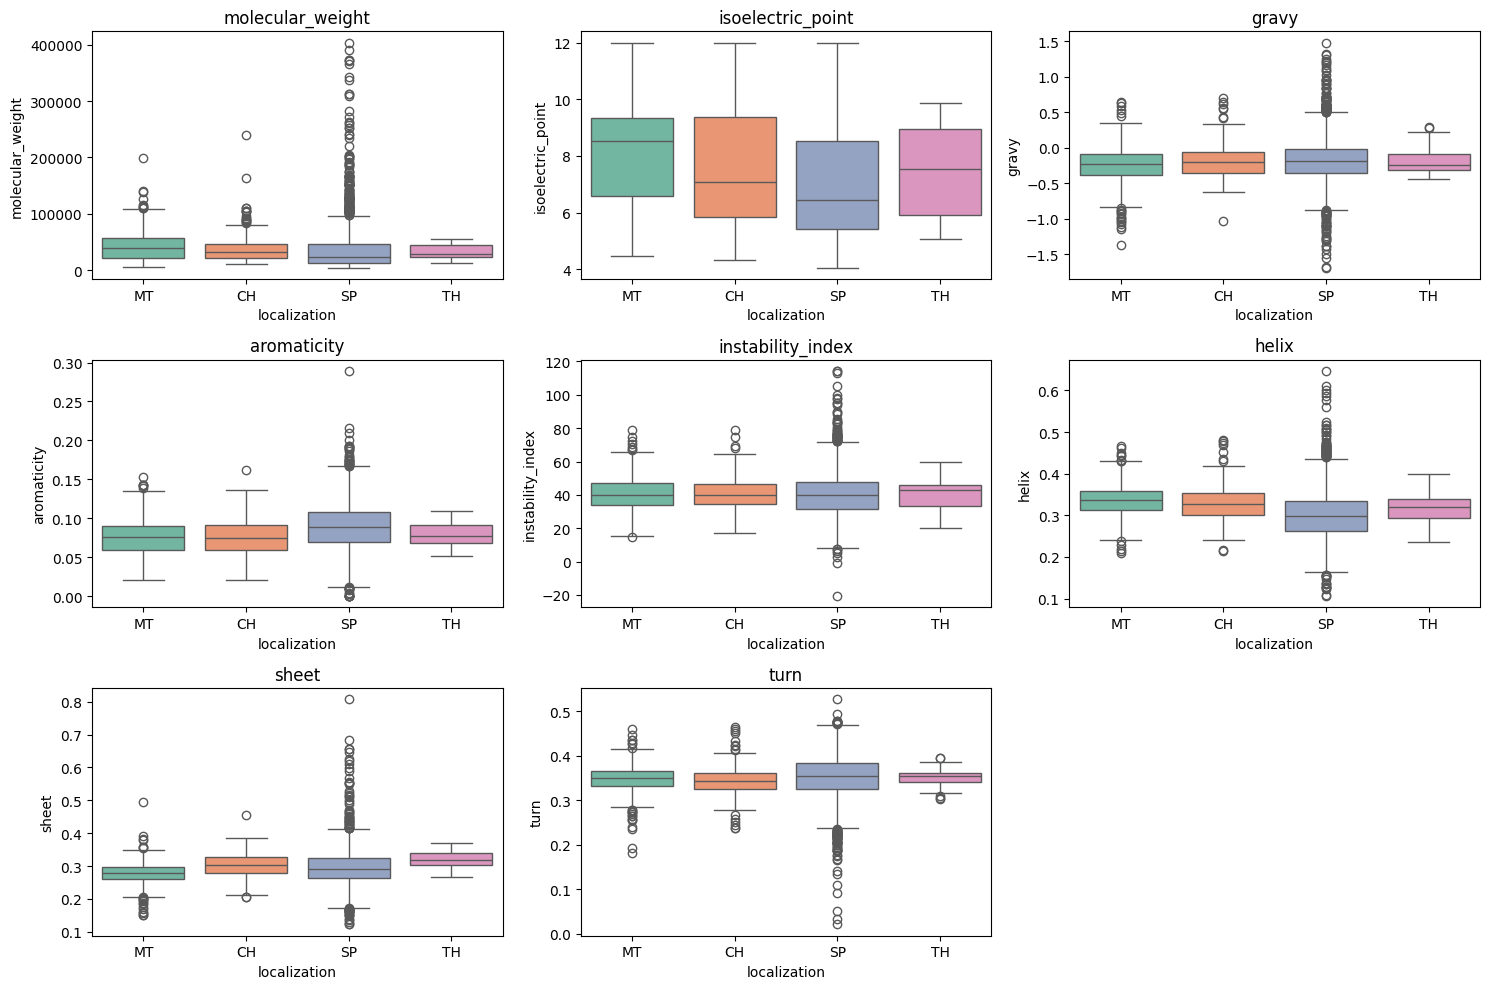

Przed SMOTE: [2157  399   36  182]
Po SMOTE: [2157 2157 2157 2157]
              precision    recall  f1-score   support

          CH       0.18      0.27      0.21        45
          MT       0.41      0.67      0.51       100
          SP       0.94      0.57      0.71       540
          TH       0.05      0.78      0.10         9

    accuracy                           0.57       694
   macro avg       0.39      0.57      0.38       694
weighted avg       0.80      0.57      0.64       694


Współczynniki regresji logistycznej (wpływ cech na klasy):
    molecular_weight  isoelectric_point  gravy  aromaticity  \
CH             0.179              0.119  0.101       -0.021   
MT             0.437              0.336 -0.162       -0.226   
SP            -0.058             -0.458  0.609        0.402   
TH            -0.559              0.003 -0.548       -0.156   

    instability_index  helix  sheet   turn  
CH             -0.044  0.501  0.384 -0.082  
MT             -0.012 -0.112 -0.

In [20]:
protein_features = merged_df["sequence"].apply(extract_protein_features)
merged_df = pd.concat([merged_df, protein_features], axis=1)
merged_df.dropna(inplace=True)

#rozwiązanie bledu zwiazanego z kolumnami
for col in ["molecular_weight", "isoelectric_point", "gravy",
            "aromaticity", "instability_index", "helix", "sheet", "turn"]:
    if col in merged_df.columns:
        merged_df.drop(columns=[col], inplace=True)
merged_df = pd.concat([merged_df, protein_features], axis=1)

#rozklad cech
plt.figure(figsize=(15, 10))
for i, col in enumerate(["molecular_weight", "isoelectric_point", "gravy",
                         "aromaticity", "instability_index", "helix", "sheet", "turn"], 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=merged_df, x="localization", y=col, hue="localization", palette="Set2")
    plt.title(col)
plt.tight_layout()
plt.show()

X = merged_df[["molecular_weight", "isoelectric_point", "gravy",
               "aromaticity", "instability_index", "helix", "sheet", "turn"]].values
y = merged_df["localization"].values

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Przed SMOTE:", np.bincount(pd.Series(y_train).factorize()[0]))
print("Po SMOTE:", np.bincount(pd.Series(y_train_res).factorize()[0]))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#standaryzacja tylko na zbiorze treningowym
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000, class_weight='balanced', solver='lbfgs')
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

coef_df = pd.DataFrame(model.coef_, columns=[
    "molecular_weight", "isoelectric_point", "gravy", "aromaticity",
    "instability_index", "helix", "sheet", "turn"
], index=model.classes_)
print("\nWspółczynniki regresji logistycznej (wpływ cech na klasy):")
print(coef_df.round(3))

Komentarz: wyniki kiepskie.

In [13]:
X = balanced_df[["length", "hydrophobic", "acidic", "basic", "polar"]].values
y = balanced_df["localization"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

#Transformacja nieliniowa równania: x1² + x2² ---
#x1=length, x2=hydrophobic
X_train_trans = np.column_stack((X_train_std[:,0]**2 + X_train_std[:,1]**2,))
X_test_trans = np.column_stack((X_test_std[:,0]**2 + X_test_std[:,1]**2,))

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_trans, y_train)

y_pred = model.predict(X_test_trans)
y_pred_proba = model.predict_proba(X_test_trans)

loss = log_loss(y_test, y_pred_proba)
acc = accuracy_score(y_test, y_pred)

print(f"Cross-Entropy (log_loss): {loss:.4f}")
print(f"Accuracy: {acc:.4f}")

print(classification_report(y_test, y_pred))

Cross-Entropy (log_loss): 1.3120
Accuracy: 0.3652
              precision    recall  f1-score   support

          CH       0.27      0.09      0.14       540
          MT       0.30      0.22      0.25       539
          SP       0.46      0.36      0.40       540
          TH       0.37      0.79      0.50       539

    accuracy                           0.37      2158
   macro avg       0.35      0.37      0.32      2158
weighted avg       0.35      0.37      0.32      2158



**Podsumowanie**

Najlepsze wyniki uzyskano dla transformacji kwadratowej, która obniżyła wartość crossentropy i zwiększyła accuracy względem modeli bazowych. Transformacja ta okazała się biologicznie uzasadniona — długość i hydrofobowość białek często w sposób nieliniowy determinują ich lokalizację: białka mitochondrialne (MT) i sygnałowe (SP) mają zwykle dłuższe, bardziej hydrofobowe presekwencje, białka chloroplastowe (CH) charakteryzują się większą polarnością i mniejszym udziałem reszt hydrofobowych.

Uzyskane wyniki potwierdzają, że uwzględnienie nieliniowych relacji między cechami fizykochemicznymi białek może istotnie poprawić jakość klasyfikacji lokalizacji komórkowej.

**Wniosek**: żaden z zaproponowanych modeli nie dał najbardziej optymalnych wyników.